In [ ]:
import torch
from torch import nn

torch.__version__

'2.10.0+cu128'

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
import os

BASE_PATH = os.path.join("content", "drive", "MyDrive")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile

dataset_path_zip = os.path.join("/content/drive/MyDrive/sepm dataset.zip")
with zipfile.ZipFile(dataset_path_zip, 'r') as zip_ref:
    zip_ref.extractall('dataset')

In [ ]:
BASE_DIR = os.path.join("content", "dataset")
dir_path = os.path.join("content", "dataset", "train")
for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

Random image path: dataset/train/ai/2f4a093522e94a6bbce412cd9fddef6d.jpg
Image class: ai
Image height: 512
Image width: 768


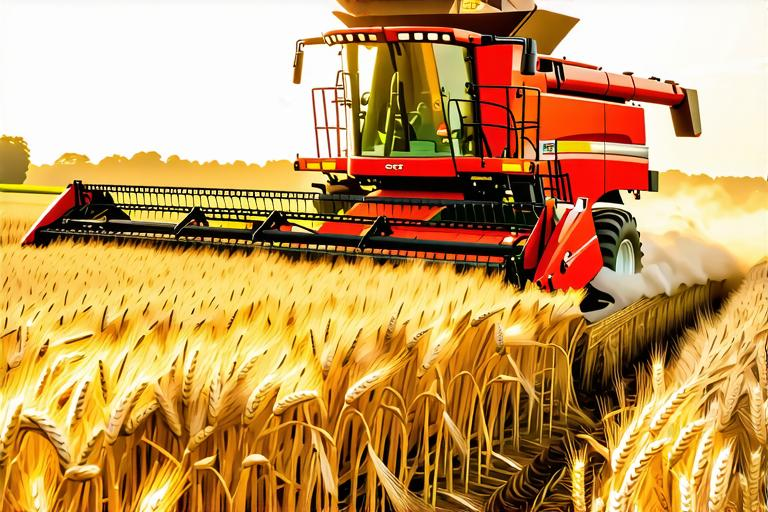

In [ ]:
import random
from PIL import Image
import glob

BASE_DIR = "dataset"
image_path = os.path.join(BASE_DIR, "train")
image_path_list = glob.glob(os.path.join(image_path, "*/*.jpg"))

random_image_path = random.choice(image_path_list)
image_class = os.path.basename(os.path.dirname(random_image_path))

img = Image.open(random_image_path)

print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

In [ ]:
from torch import nn
from torchvision import transforms

manual_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

train_data = datasets.ImageFolder(
    root=os.path.join(BASE_DIR, "train"),
    transform=manual_transforms,
    target_transform=None
)

In [ ]:
train_data.classes

['ai', 'real']

In [ ]:
train_data.class_to_idx

{'ai': 0, 'real': 1}

In [ ]:
len(train_data)

79950

In [ ]:
img, label = train_data[0][0], train_data[0][1]
print(f"Image tensor:\n{img}")
print(f"Image shape: {img.shape}")
print(f"Image datatype: {img.dtype}")
print(f"Image label: {label}")
print(f"Label datatype: {type(label)}")

Image tensor:
tensor([[[ 0.4679, -0.3198,  0.1426,  ...,  2.0948,  2.0948,  2.0434],
         [ 0.7419,  0.1768,  0.4337,  ...,  2.1290,  2.1462,  2.1804],
         [-0.1486,  0.2111,  0.3823,  ...,  2.1633,  2.1804,  2.1975],
         ...,
         [-0.7993, -1.1418, -1.0904,  ..., -1.4843, -1.4672, -1.4672],
         [-1.0904, -1.2959, -1.1589,  ..., -1.4158, -1.3987, -1.3987],
         [-1.2103, -1.3987, -1.2445,  ..., -1.3815, -1.3644, -1.3644]],

        [[-0.2325, -1.0378, -0.4776,  ...,  2.2710,  2.2710,  2.2185],
         [ 0.1352, -0.4601, -0.1450,  ...,  2.3060,  2.3235,  2.3585],
         [-0.6176, -0.3200, -0.1275,  ...,  2.3410,  2.3585,  2.3761],
         ...,
         [-1.5105, -1.7031, -1.7031,  ..., -0.7927, -0.7752, -0.7577],
         [-1.6331, -1.7206, -1.6681,  ..., -0.7577, -0.7402, -0.7227],
         [-1.6506, -1.7206, -1.7031,  ..., -0.7227, -0.7052, -0.6877]],

        [[-0.9330, -1.5779, -1.0550,  ...,  2.4831,  2.4831,  2.4308],
         [-0.5321, -0.9678, -0.

In [ ]:
from torch.utils.data import dataloader

train_dataloader = DataLoader(
    dataset=train_data,
    batch_size=32,
    num_workers=1,
    shuffle=True
)

train_dataloader

In [ ]:
img, label = next(iter(train_dataloader))
print(f"Image shape: {img.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label.shape}")

Image shape: torch.Size([32, 3, 224, 224]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([32])


In [ ]:
import torchvision

weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
weights

EfficientNet_B0_Weights.IMAGENET1K_V1

In [ ]:
auto_transforms = weights.transforms()
auto_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

In [ ]:
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
model = torchvision.models.efficientnet_b0(weights=weights).to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 165MB/s]


In [ ]:
for param in model.features.parameters():
    param.requires_grad = False

In [ ]:
output_shape = len(train_data.classes)

model.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(
        in_features=1280,
        out_features=output_shape,
        bias=True
    )
).to(device)

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
from tqdm import tqdm

epochs = 20

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    progress_bar = tqdm(
        train_dataloader,
        desc=f"Epoch {epoch+1}/{epochs}",
        leave=False
    )

    for batch_idx, (inputs, targets) in enumerate(progress_bar):
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = loss_fn(outputs, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        avg_loss = running_loss / (batch_idx + 1)

        # Update tqdm bar
        progress_bar.set_postfix({
            "batch_loss": f"{loss.item():.4f}",
            "avg_loss": f"{avg_loss:.4f}"
        })

    epoch_loss = running_loss / len(train_dataloader)

    print(f"\n✅ Epoch [{epoch+1}/{epochs}] completed | Avg Loss: {epoch_loss:.4f}")


✅ Epoch [1/20] completed | Avg Loss: 0.2939



✅ Epoch [2/20] completed | Avg Loss: 0.2743



✅ Epoch [3/20] completed | Avg Loss: 0.2733



✅ Epoch [4/20] completed | Avg Loss: 0.2759



✅ Epoch [5/20] completed | Avg Loss: 0.2736


...


✅ Epoch [16/20] completed | Avg Loss: 0.2783



✅ Epoch [17/20] completed | Avg Loss: 0.2750



✅ Epoch [18/20] completed | Avg Loss: 0.2774



✅ Epoch [19/20] completed | Avg Loss: 0.2756



✅ Epoch [20/20] completed | Avg Loss: 0.2742


In [ ]:
torch.save(model.state_dict(), "veriface_v2.pth")

In [ ]:
! pip install onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 70.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 17.8 MB/s eta 0:00:00


In [ ]:
import torch

# Set model to evaluation mode
model.eval()

# Example input shape for MobileNet-like models
# (batch_size, channels, height, width)
dummy_input = torch.randn(1, 3, 224, 224).to(device)

# Export to ONNX
torch.onnx.export(
    model,
    dummy_input,
    "veriface_v2.onnx",
    export_params=True,
    opset_version=12,          # slightly newer, safer
    do_constant_folding=True,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={
        "input": {0: "batch_size"},
        "output": {0: "batch_size"}
    }
)

print("✅ Model exported successfully to veriface_v2.onnx")

/tmp/ipykernel_1603/2773818280.py:11: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0326 09:04:03.889000 1603 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 12 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0326 09:04:05.761000 1603 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, a

[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


[torch.onnx] Translate the graph into ONNX... ✅


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/adapters/axes_input_to_attribute.h:65: adapt: Asserti

Applied 99 of general pattern rewrite rules.
✅ Model exported successfully to veriface_v2.onnx
